In [1]:
import pandas as pd
import numpy as np

def clean_country(filepath, country_name):
        df = pd.read_csv(filepath)
        df['Country'] = country_name
        df = df.replace([-999, -999.0], np.nan)

        df = df.drop_duplicates()

        df['Date'] = pd.to_datetime(
            df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3),
            format= '%Y%j'
        )

        df['Month'] = df['Date'].dt.month
        return df

In [2]:
ethiopia = clean_country('../data/raw/ethiopia (1).csv', 'Ethiopia')
kenya = clean_country('../data/raw/kenya (1).csv', 'Kenya')
sudan = clean_country('../data/raw/sudan.csv', 'Sudan')
nigeria = clean_country('../data/raw/nigeria (1).csv', 'Nigeria')
tanzania = clean_country('../data/raw/tanzania.csv', 'Tanzania')


df_all = pd.concat([ethiopia, kenya, sudan, tanzania, nigeria], ignore_index=True)

print(df_all.shape)
print(df_all['Country'].value_counts())


(20540, 15)
Country
Ethiopia    4108
Kenya       4108
Sudan       4108
Tanzania    4108
Nigeria     4108
Name: count, dtype: int64


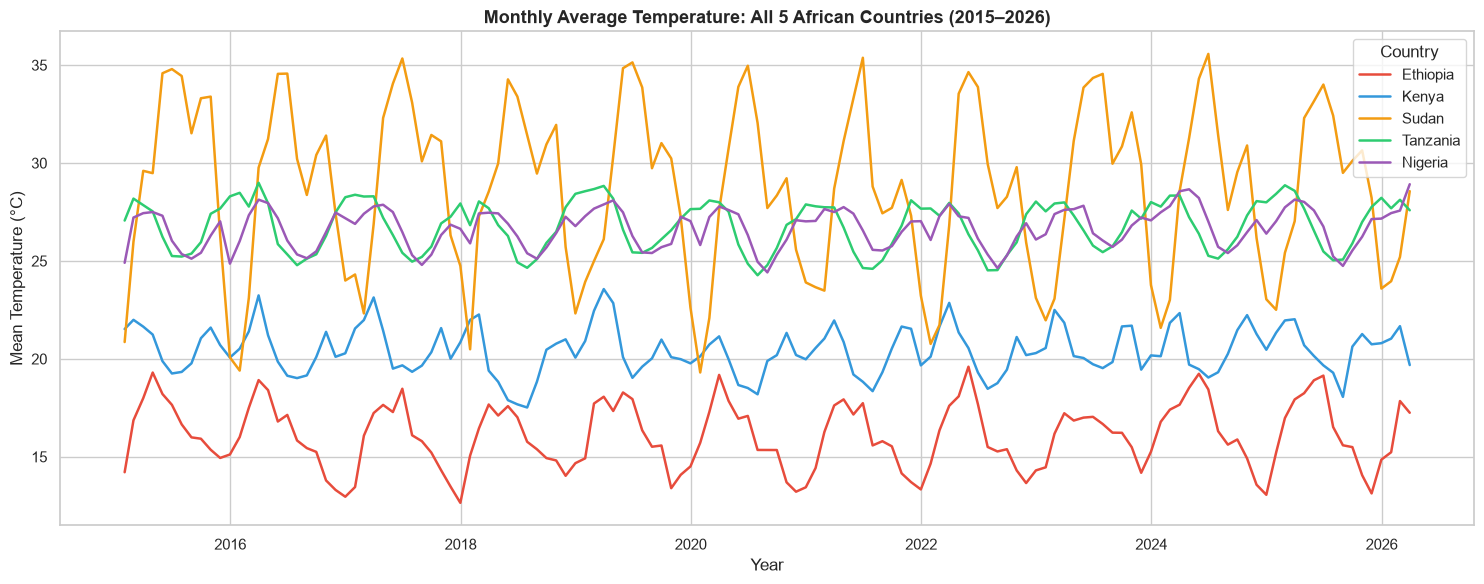

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Group by Country and Date (monthly), then compute mean T2M
df_indexed = df_all.set_index('Date')

# For each country, resample monthly mean temperature
plt.figure(figsize=(15, 6))

colors = {
    'Ethiopia': '#e74c3c',
    'Kenya':    '#3498db',
    'Sudan':    '#f39c12',
    'Tanzania': '#2ecc71',
    'Nigeria':  '#9b59b6'
}

for country in df_all['Country'].unique():
    country_data = df_indexed[df_indexed['Country'] == country]['T2M']
    monthly_avg = country_data.resample('ME').mean()
    plt.plot(monthly_avg.index, monthly_avg.values,
             label=country,
             color=colors[country],
             linewidth=1.8)

plt.title('Monthly Average Temperature: All 5 African Countries (2015–2026)',
          fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Mean Temperature (°C)')
plt.legend(title='Country')
plt.tight_layout()
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_24220\3830271037.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_24220\3830271037.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


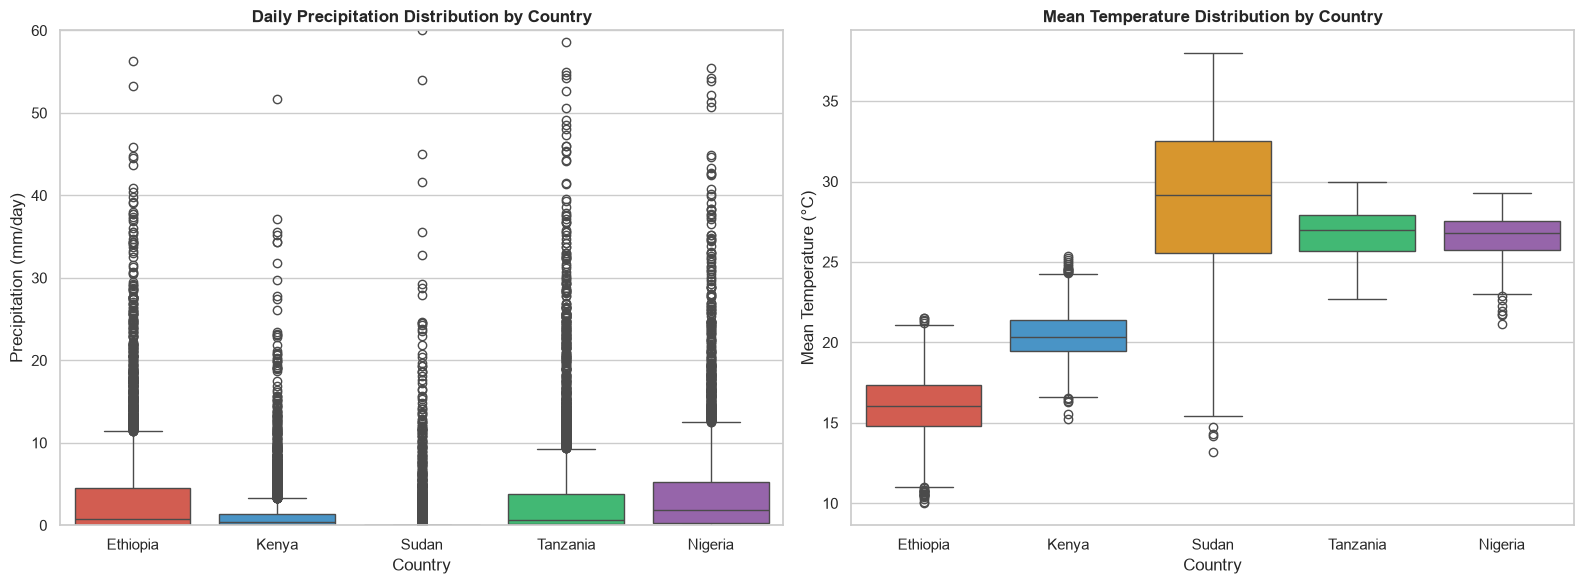


--- Climate Summary Statistics by Country ---
            T2M              PRECTOTCORR             
           mean median   std        mean median   std
Country                                              
Ethiopia  16.07  16.04  1.90        3.63   0.82  6.29
Kenya     20.43  20.36  1.44        1.47   0.38  3.18
Nigeria   26.66  26.82  1.12        4.21   1.84  7.27
Sudan     28.76  29.16  4.68        0.64   0.00  3.06
Tanzania  26.80  26.99  1.33        3.74   0.64  8.00


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1: Boxplot of Daily Precipitation by Country ---
sns.boxplot(
    ax=axes[0],
    data=df_all,
    x='Country',
    y='PRECTOTCORR',
    palette=colors,
    order=['Ethiopia', 'Kenya', 'Sudan', 'Tanzania', 'Nigeria']
)
axes[0].set_title('Daily Precipitation Distribution by Country', fontweight='bold')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Precipitation (mm/day)')
axes[0].set_ylim(0, 60)  # Focus on main distribution

# --- Chart 2: Boxplot of Mean Temperature by Country ---
sns.boxplot(
    ax=axes[1],
    data=df_all,
    x='Country',
    y='T2M',
    palette=colors,
    order=['Ethiopia', 'Kenya', 'Sudan', 'Tanzania', 'Nigeria']
)
axes[1].set_title('Mean Temperature Distribution by Country', fontweight='bold')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Mean Temperature (°C)')

plt.tight_layout()
plt.show()

# --- Summary Statistics Table ---
summary = df_all.groupby('Country')[['T2M', 'PRECTOTCORR']].agg(['mean', 'median', 'std']).round(2)
print("\n--- Climate Summary Statistics by Country ---")
print(summary)


In [ ]:
# ========================================================
# Seasonal Rainfall Cycle & Annual Total Rainfall Trends
# ========================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Left Chart: Monthly Seasonal Cycle (Calendar Months 1-12)
# Step A: Total rain per specific year-month
monthly_totals = df_all.groupby(['Country', 'YEAR', 'Month'])['PRECTOTCORR'].sum().reset_index()

# Step B: Average rainfall for each calendar month (Jan-Dec)
seasonal_cycle = monthly_totals.groupby(['Country', 'Month'])['PRECTOTCORR'].mean().reset_index()

sns.lineplot(
    ax=axes[0],
    data=seasonal_cycle,
    x='Month',
    y='PRECTOTCORR',
    hue='Country',
    palette=colors,
    marker='o',
    linewidth=2
)
axes[0].set_title('Seasonal Rainfall Pattern (Calendar Months 1–12)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Monthly Rainfall (mm)')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0].legend(title='Country')

# 2. Right Chart: Annual Total Rainfall Trend (2015-2026)
annual_precip = df_all.groupby(['Country', 'YEAR'])['PRECTOTCORR'].sum().reset_index()

sns.lineplot(
    ax=axes[1],
    data=annual_precip,
    x='YEAR',
    y='PRECTOTCORR',
    hue='Country',
    palette=colors,
    marker='s',
    linewidth=2
)
axes[1].set_title('Annual Total Rainfall Trend (2015–2026)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Annual Rainfall (mm/year)')
axes[1].legend(title='Country')

plt.tight_layout()
plt.show()

# Print average annual rainfall for each country
avg_annual = annual_precip.groupby('Country')['PRECTOTCORR'].mean().round(1).sort_values(ascending=False)
print('--- Average Annual Rainfall per Country (mm/year) ---')
print(avg_annual)


In [ ]:
# ========================================================
# Climate Variable Correlations across Countries
# ========================================================
features = ['T2M', 'PRECTOTCORR', 'RH2M', 'WS2M', 'PS']
countries = ['Ethiopia', 'Kenya', 'Sudan', 'Tanzania', 'Nigeria']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for i, country in enumerate(countries):
    subset = df_all[df_all['Country'] == country][features]
    corr_matrix = subset.corr()
    
    sns.heatmap(
        corr_matrix,
        ax=axes[i],
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        cbar=(i == 4)
    )
    axes[i].set_title(f'{country} Correlations', fontweight='bold', fontsize=12)

plt.suptitle('Climate Feature Correlation Matrices by Country', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Summary of correlation with precipitation
precip_corr = {}
for country in countries:
    subset = df_all[df_all['Country'] == country]
    precip_corr[country] = subset[features].corr()['PRECTOTCORR']

df_precip_corr = pd.DataFrame(precip_corr).T.drop(columns=['PRECTOTCORR']).round(3)
print('--- Correlation with Daily Precipitation (PRECTOTCORR) ---')
print(df_precip_corr)


## Key Findings & Machine Learning Insights

### 1. Temperature Dynamics (T2M)
- **Sudan** experiences the highest average temperatures (~28-30 C) with wide seasonal swings.
- **Kenya and Ethiopia** exhibit cooler, stable average temperatures due to higher average elevation and plateau geography.
- Seasonal temperature swings are minimal near the equator (Kenya/Tanzania), but prominent in the north (Sudan).

### 2. Precipitation Volumes & Drought Vulnerability (PRECTOTCORR)
- **High Rainfall Group**: Nigeria (~1,443 mm/year), Tanzania (~1,280 mm/year), and Ethiopia (~1,244 mm/year).
- **Arid / Semi-Arid Group**: Kenya (~503 mm/year) and Sudan (~220 mm/year).
- **Drought Risk**: Sudan and Kenya operate on razor-thin rainfall margins. A 20% deficit in Sudan triggers severe desertification and crop failure.

### 3. Distinct Seasonal Signatures (Unimodal vs. Bimodal)
- **Ethiopia (Unimodal Summer)**: Main rainy season (*Kiremt*) peaks intensely in July and August (~300 mm/month).
- **Kenya (Bimodal Dual-Peak)**: Two distinct rainy seasons - *Long Rains* (April) and *Short Rains* (November) - with dry periods in between.
- **Tanzania (Southern East Africa)**: Extended wet season from November through May, followed by a dry winter (June-September).
- **Sudan**: Very short, sharp rainy window concentrated exclusively in July-August.

### 4. Machine Learning & Feature Engineering Implications
- **Conditioning on Country**: A raw calendar date (e.g. Month = 7) has opposite meanings across countries (July is peak rain in Ethiopia, but dry season in Tanzania). Models must include Country as a categorical feature or use geographical coordinates (Latitude, Longitude).
- **Strongest Predictor of Rain**: Across all 5 countries, **Relative Humidity (RH2M)** shows the strongest positive linear correlation with precipitation (+0.35 to +0.51).
- **Non-Linearity of Rain**: Daily temperature alone has near-zero linear correlation with daily rain. Models predicting rainfall or extreme climate events must capture non-linear interactions (e.g. using tree-based ensembles or neural networks) between humidity, pressure, and temperature.
